In [6]:
# change working directory to the same as the one running on springfield
import os
from pathlib import Path
if os.getcwd()[-5:] == "Icing":
    os.chdir(Path(os.getcwd()) / "hi")

# clear the cache
%rm -r __pycache__/


### Libraries

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
# from torch_incremental_pca import IncrementalPCA

# custom wrapper for many cv2 functions
from video import load_and_show, filter_frame, normalize_brightness, set_frame, get_num_frames
from mask_creation import get_mask



### Directories

In [8]:

figure_dir          = Path(os.getcwd()) / "figures"
data_dir            = Path(os.getcwd()) / "video-data"
polygon_dir         = Path(os.getcwd()) / "polygons"
case_videos_dir     = Path(os.getcwd()) / "case_videos"
segnet_output_dir   = Path(os.getcwd()) / "segnet_output"
scan_output_dir     = Path(os.getcwd()) / "scan_output"
reduced_video_dir   = Path(os.getcwd()) / "reduced_video_data"


In [9]:
# load the video and load the mask
video_filename = "Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"
video_path = data_dir / video_filename 
# video_path = "video-data/Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"
cap = cv2.VideoCapture(video_path)
set_frame(cap, 0)

from mask_creation import reduced_frame_polygon, create_mask

red = cv2.VideoCapture(reduced_video_dir / video_filename)
_, frame = red.read()
polygon = reduced_frame_polygon(frame)
red_mask = create_mask(polygon, frame.shape)

mask = get_mask(cap, plot_mask=False, figure_dir=figure_dir, which_polygon="yb")

# print("", flush=True)
# display("", clear=True) # to remove the cv2 warnings

[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] no frame!
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] no frame!
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] no frame!
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x33c5ea00] non-existing PPS 0 referenced
[h264 @ 0x

In [10]:
# from video import write_lower_right_corner_reduced

# write_lower_right_corner_reduced(cap, reduced_video_dir / video_filename)

### Threshold optimization

In [13]:
thresholds = np.load(scan_output_dir / "thresholds_springfield.npy")
silhouette_scores = np.load(scan_output_dir / "silhouette_scores_springfield.npy")
HSV = np.load(scan_output_dir / "HSV_springfield.npy")


In [18]:

def HSV_plot(HSV, threshold):
    H = HSV[:, 0]
    S = HSV[:, 1]
    V = HSV[:, 2]
    iceness = 1/(S+V)
    labels = iceness > threshold
    fig, axs=plt.subplots(1, 3)
    axs[0].scatter(H[labels==0], S[labels==0], c="tab:blue", label="0")
    axs[0].scatter(H[labels==1], S[labels==1], c="tab:orange", label="1")
    axs[1].scatter(H[labels==0], V[labels==0], c="tab:blue", label="0")
    axs[1].scatter(H[labels==1], V[labels==1], c="tab:orange", label="1")
    axs[2].scatter(S[labels==0], V[labels==0], c="tab:blue", label="0")
    axs[2].scatter(S[labels==1], V[labels==1], c="tab:orange", label="1")
    axs[0].set_xlabel("H")
    axs[0].set_ylabel("S")
    axs[1].set_xlabel("H")
    axs[1].set_ylabel("V")
    axs[2].set_xlabel("S")
    axs[2].set_ylabel("V")
    for ax in axs: ax.legend()
    fig.tight_layout()

def remove_nans(thresholds, silhouette_scores):
    t_ = []
    s_ = []
    for ts, ss in zip(thresholds, silhouette_scores):
        if not np.isnan(ss):
            t_.append(ts)
            s_.append(ss)
    return np.array(t_), np.array(s_)


t, s = remove_nans(thresholds, silhouette_scores)
fig, ax=plt.subplots()
ax.plot(t, s)
ax.scatter(t[s == s.max()], 
           s[s == s.max()],
           c="r")
ax.set_xlabel("Threshold")
ax.set_ylabel("Silhouette score")
ax.set_title("Threshold optimization")
fig.savefig(figure_dir / "thresholds-silhouette.png")
HSV_plot(HSV, t[s == s.max()][0])
plt.close("all")

In [ ]:
stop

NameError: name 'stop' is not defined

### Test iceness index method

In [ ]:
from ice_noice import icenessindex

def live_tester(start):
    # open video at start
    i = start
    cap.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    fig, axs=plt.subplots(5, 1)
    axs[0].set_title("Iceness")
    axs[1].set_title("Ice indicator")
    plt.close("all")
    ice_history = []
    icenesshistory = []
    Hs = []
    Ss  = []
    Vs = []
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        cv2.imshow("..", frame)

        # filter the frame and normalize it
        frame_filtered = frame * mask[:, :, None]

        # normalize
        frame_filtered = normalize_brightness(frame_filtered, mask)

        iceness, isice, H, S, V = icenessindex(frame_filtered)

        ice_history.append(isice * 1.0 if isice else 0.0) 
        icenesshistory.append(iceness)

        Hs.append(H)
        Ss.append(S)
        Vs.append(V)

        axs[0].plot(icenesshistory, c="k")
        axs[1].plot(ice_history, c="k")
        axs[2].plot(Hs)
        axs[3].plot(Ss)
        axs[4].plot(Vs)

        
        fig.savefig(figure_dir / "yellow history.png")

        key = cv2.waitKey(1)
        if key == ord("q"):
            break

        if key == ord("i"):
            for i in range(len(axs)):
                axs[i].axvline(len(icenesshistory)-1)

        elif key == ord(" "):
            k = cv2.waitKey(0)
            if k == ord(" "):
                continue
            elif k == ord("q"):
                break
        increase = 100
        for _ in range(increase - 1):
            # grab but dont decdoe
            cap.grab()


        i += increase
    cv2.destroyAllWindows()
    
# live_tester(0)

In [ ]:
stop

NameError: name 'stop' is not defined

## Legacy

### Frame histograms 

In [ ]:
from video import normalize_brightness
# define bins used for all histograms
bins = np.arange(0, 256, 5)


def channel_histogram(pixels, density=True):
    # get counts (density)
    counts_blue, _ = np.histogram(pixels[:, 0], bins, density=density)
    counts_green, _ = np.histogram(pixels[:, 1], bins, density=density)
    counts_red, _ = np.histogram(pixels[:, 2], bins, density=density)
    return counts_blue, counts_green, counts_red

def plot_frame_and_histogram(frame, histograms):

    ch1, ch2, ch3 = histograms

    fig, axs=plt.subplots(3, 1)

    axs[0].plot(bins[:-1], ch1)
    axs[1].plot(bins[:-1], ch2)
    axs[2].plot(bins[:-1], ch3)

    axs[0].set_title("blue", c="blue")
    axs[1].set_title("green", c="green")
    axs[2].set_title("red", c="red")
    fig.tight_layout()

    fig.savefig(figure_dir / "histogram.png")
    plt.close()

    # write the frame itself
    cv2.imwrite(figure_dir / "image.png", frame)



def frame_histogram(videocapture, target_frame_index, mask, savefigs=True, searchup=True):
    """
    load a particular frame index in the video capture
    """
    if searchup:
        set_frame(videocapture, target_frame_index)

    ret, frame = cap.read()

    if not ret:
        return 

    frame_filtered = filter_frame(frame, mask)
    frame_filtered = normalize_brightness(frame_filtered, mask)
    valid_pixels = extract_pixels_in_mask(frame_filtered, mask)


    histograms = channel_histogram(valid_pixels, density=True)
    counts_blue, counts_green, counts_red = histograms

    if savefigs:
        plot_frame_and_histogram(frame_filtered, histograms)
    
    return {
        "counts_blue": counts_blue,
        "counts_green": counts_green,
        "counts_red": counts_red,
    }

# target_frame = 10000
# target_frame = 4000
target_frame = 1000
histogram_dict = frame_histogram(cap, target_frame, mask, savefigs=0)

### Manually specified ice / noice regions 

In [ ]:
# the following loops have been used to establish a ice and a no-ice area
target_frame = 10000 - 1000
for addition in range(0, 10000, 10):
    break    
    extract_im_and_hist(cap, target_frame+addition, mask)
    time.sleep(0.05)

target_frame = 0
for addition in range(0, 5000, 100):
    break
    extract_im_and_hist(cap, target_frame+addition, mask=np.ones(frame_shape))
    time.sleep(0.1)

icing_frames = 10000-1000, 10000-1000 + 10000
noicing_frames = 0, 5000

### Segmentation model 

#### Segment Anything Model (SAM)

In [ ]:
# from sam import load_sam

# model = load_sam()
# print(model)
# import requests
# import torch
# from PIL import Image

# from transformers import SamModel, SamProcessor

# model = SamModel.from_pretrained("facebook/sam-vit-base", device_map="auto")
# processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

# img_url = "https://huggingface.co/ybelkada/segment-anything/resolve/main/assets/car.png"
# raw_image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")
# input_points = [[[450, 600]]]  # 2D location of a window in the image

# inputs = processor(raw_image, input_points=input_points, return_tensors="pt").to(model.device)
# with torch.no_grad():
#     outputs = model(**inputs)

# masks = processor.image_processor.post_process_masks(
#     outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
# )
# scores = outputs.iou_scores
# masks = processor.image_processor.post_process_masks(
#     outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
# )
# scores = outputs.iou_scores

#### SegNet

In [ ]:
# get and image from the video
set_frame(cap, 0)
ret, frame = cap.read()
if not ret: print("Error")
image = torch.tensor(frame)
image = image.to(torch.float32) / 255.0
image = image.unsqueeze(0)
image = image.permute(0, 3, 1, 2)
print(f"{image.shape = }")



image.shape = torch.Size([1, 3, 720, 1280])


In [ ]:
out = torch.load(segnet_output_dir / "out")
out = out.squeeze(0)
out = out.permute(1, 2, 0)
out = (out * 255).to(torch.uint8)
out = out.cpu().detach().numpy()


In [ ]:
print(f"{out.shape = }")
frame = out[:, :, 0]
print(f"{frame.shape = }")
print(frame)
cv2.imwrite(figure_dir / "SegNet output.png", frame)

out.shape = (360, 640, 2)
frame.shape = (360, 640)
[[138 151 154 ... 141 102 133]
 [152 141 169 ... 144 143 141]
 [172 150 161 ... 153 169 160]
 ...
 [148 136 154 ... 134 151 141]
 [148 153 154 ... 161 168 146]
 [153 141 171 ... 151 147 149]]


True

### Analyze case seperation indicies

frame_indicies_ice.shape = (59533,)
frame_indicies_noice.shape = (42903,)


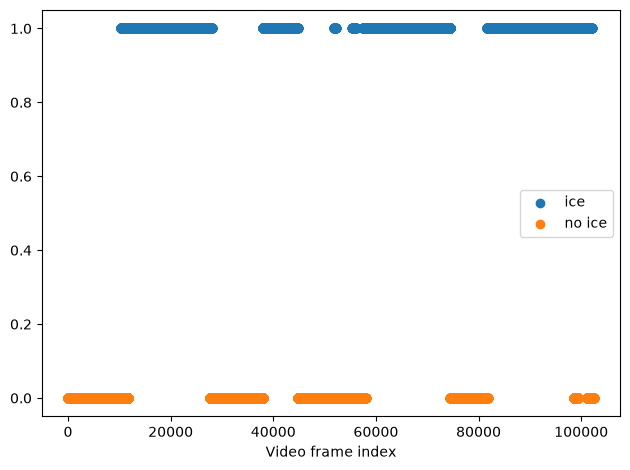

In [ ]:
frame_indicies_ice = np.load(case_videos_dir / "frame_indicies_ice.npy")
frame_indicies_noice = np.load(case_videos_dir / "frame_indicies_noice.npy")

print(f"{frame_indicies_ice.shape = }")
print(f"{frame_indicies_noice.shape = }")

fig, ax=plt.subplots()
ax.scatter(frame_indicies_ice, np.ones_like(frame_indicies_ice), label="ice")
ax.scatter(frame_indicies_noice, np.zeros_like(frame_indicies_noice), label="no ice")
ax.set_xlabel("Video frame index")
ax.legend(); fig.tight_layout()


### Use iceness index to split video into ice / no-ice

Using the regions of interest, we should be able to split the original video into two videos 

In [ ]:
output_icing_path = outputvideos_dir / ("icing_" + video_filename)
output_noicing_path = outputvideos_dir / ("noicing_" + video_filename)
split_video_into_ice_noice = 0


def split_into_ice_noice(videocapture, output_icing, output_noicing, increase=100, num_frames = 1000, ):
    # open video at beginning 
    i = 0
    videocapture.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    frame_indicies_ice = []
    frame_indicies_noice = []

    num_dp = 1
    while cap.isOpened():

        ret, frame = videocapture.read()
        if not ret:
            break

        frame_filtered = frame * mask[:, :, None]

        frame_filtered_normalized = normalize_brightness(frame_filtered)

        _, isice = icenessindex(frame_filtered_normalized)

        if isice:
            output_icing.write(frame)
            frame_indicies_ice.append(i)
        else:
            output_noicing.write(frame)
            frame_indicies_noice.append(i)


        if num_dp == num_frames and num_frames:
            break

        for _ in range(increase):
            videocapture.grab()
        num_dp += 1
        i += increase

    output_icing.release()
    output_noicing.release()
    cv2.destroyAllWindows()
    frame_indicies_ice = np.array(frame_indicies_ice)
    frame_indicies_noice = np.array(frame_indicies_noice)
    np.save(outputvideos_dir / "frame_indicies_ice.npy", frame_indicies_ice)
    np.save(outputvideos_dir / "frame_indicies_noice.npy", frame_indicies_noice)

if split_video_into_ice_noice:

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    ret, frame = cap.read()
    frame_shape = frame.shape
    width, height = frame_shape[1], frame_shape[0]
    # from
    # https://learnopencv.com/reading-and-writing-videos-using-opencv/
    output_icing = cv2.VideoWriter(output_icing_path,
                                cv2.VideoWriter_fourcc(*'XVID'), 20, (width, height))
    output_noicing = cv2.VideoWriter(output_noicing_path,
                                    cv2.VideoWriter_fourcc(*'XVID'), 20, (width, height))

    split_into_ice_noice(cap, output_icing, output_noicing, 100, 0)




NameError: name 'outputvideos_dir' is not defined

In [ ]:
frame_indicies_ice = np.load(outputvideos_dir / "frame_indicies_ice.npy")
frame_indicies_noice = np.load(outputvideos_dir / "frame_indicies_noice.npy")

In [ ]:
show_noicing = 0
show_icing = 0


cap_noicing = cv2.VideoCapture(output_noicing_path)
cap_icing = cv2.VideoCapture(output_icing_path)

total_frames_noicing = int(cap_noicing.get(cv2.CAP_PROP_FRAME_COUNT))
total_frames_icing = int(cap_icing.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"{total_frames_noicing = }")
print(f"{total_frames_icing = }")

cap_noicing.set(cv2.CAP_PROP_POS_FRAMES, 0)


def show_noicing_video():
    while cap_noicing.isOpened():
        ret, frame = cap_noicing.read()

        if not ret:
            break

        cv2.imshow("No Icing", frame)

        key = cv2.waitKey(0)
        if key == ord("q"):
            break

def show_icing_video():
    cap_icing.set(cv2.CAP_PROP_POS_FRAMES, 0)
    i = 0
    while cap_icing.isOpened():
        ret, frame = cap_icing.read()

        if not ret:
            break

        # if i == total_frames_icing // 2:
        #     break

        cv2.imshow("Icing", frame)

        key = cv2.waitKey(0)
        if key == ord("q"):
            break
        i+=1


if show_noicing:
    show_noicing_video()
if show_icing:
    show_icing_video()



total_frames_noicing = -1
total_frames_icing = -1


In [ ]:
cap_ice = cv2.VideoCapture(output_icing_path)
total_frames_ice = int(cap_ice.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Loaded video with {total_frames_ice} frames")

Loaded video with -1 frames


In [ ]:
print(f"{mask.shape = }")
mask_height, mask_width = mask.shape
# make an array of all the pixels with ice
n_frames = 629//2
pixels_ice = np.zeros((n_frames, mask.sum(), 3), dtype=np.uint8)
cap_ice.set(cv2.CAP_PROP_POS_FRAMES, 0)   
i = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break    
    frame = frame * mask[:, :, None]   
    frame = normalize_brightness(frame, mask)
    pixels = frame[mask==1]
    pixels_ice[i, :, 0] = pixels[:, 0]
    pixels_ice[i, :, 1] = pixels[:, 1]
    pixels_ice[i, :, 2] = pixels[:, 2]

    if i == n_frames - 1:
        break
    i += 1


pixels_ice = np.array(pixels_ice)#.reshape((-1, 3))
pixels_ice_flat = pixels_ice.reshape((n_frames, -1))
sample_size = pixels_ice.shape[1]


mask.shape = (720, 1280)


In [ ]:
n_components = 2
ipca = IncrementalPCA(n_components)
ipca.fit(pixels_ice_flat)

KeyboardInterrupt: 

In [ ]:
components = ipca.components_.reshape((n_components, sample_size, 3))
print(f"{components.shape = }")


In [ ]:
reduced = ipca.transform(pixels_ice_flat)


In [ ]:

print(f"{reduced.shape = }")
fig, ax = plt.subplots()
ax.scatter(reduced[:-len(reduced[:, 0])//2, 0], 
           reduced[:-len(reduced[:, 0])//2, 1], label="First quater")
ax.scatter(reduced[len(reduced[:, 0])//2:, 0], 
           reduced[len(reduced[:, 0])//2:, 1], label="second quater")
ax.legend()